In this notebook, we explore the number of templates stuff

In [3]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import matplotlib.ticker as mticker
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import glob
from matplotlib.lines import Line2D

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/nebular_stuff'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/stacking_analysis'))


from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, process_img
from desi_lowz_funcs import calc_normalized_dist, sdss_rgb, get_scrollable_pdfs
from desi_lowz_funcs import find_objects_nearby, print_radecs
# from construct_dwarf_galaxy_catalogs import process_sga_matches

import warnings
from astropy.wcs import FITSFixedWarning

from desi_lowz_funcs import plot_2d_dist, make_subplots

# Suppress just FITSFixedWarning
warnings.filterwarnings('ignore', category=FITSFixedWarning)

from sfr_and_metallicity import compute_o32, compute_r32
from sfr_and_metallicity import line_snr_mask
from catalog_paper_plots import make_cmap
from catalog_paper_plots import make_cmap
import cmasher as cmr
from scipy.stats import gaussian_kde

from pn_functions import compute_direct_metallicities

%load_ext autoreload
%autoreload 2




In [4]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [3]:
from astropy.table import Table
tab = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/ntemplate_scan/ntemplate_scan_summary.csv")
n_arr = tab["n_templates"]

In [28]:
path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/ncomponent_scan/pca_scan_per_component.npz"
d = np.load(path)

# See what's inside
print(d.files)
# ['S', 'S_null', 'evr_train', 'cum_evr_train', 'evr_valid', 'cum_evr_valid',
#  'recon_mse_valid', 'first_below_null']

# Access arrays by name
S = d["S"]
S_null = d["S_null"]
evr_train = d["evr_train"]
cum_evr_train = d["cum_evr_train"]
evr_valid = d["evr_valid"]
cum_evr_valid = d["cum_evr_valid"]
recon_mse_valid = d["recon_mse_valid"]
first_below_null = int(d["first_below_null"])

['S', 'S_null', 'evr_train', 'cum_evr_train', 'evr_valid', 'cum_evr_valid', 'recon_mse_valid', 'first_below_null']


In [56]:
print(d["cum_evr_train"][-1])   # should be 1.0
print(d["cum_evr_train"][19])   # ~value at k=20
print(d["cum_evr_valid"][19])   # validation at k=20

1.0003242
0.42495275
0.4388197


In [41]:
cum_evr_train.shape

(3980,)

In [48]:
# resids = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/norm_residuals_dwarfs_NEW.npy")

In [47]:
# n_gal, n_pix = resids.shape
# print(n_pix)                                 # likely 3980
# print("r should be min(n_train, n_pix)")

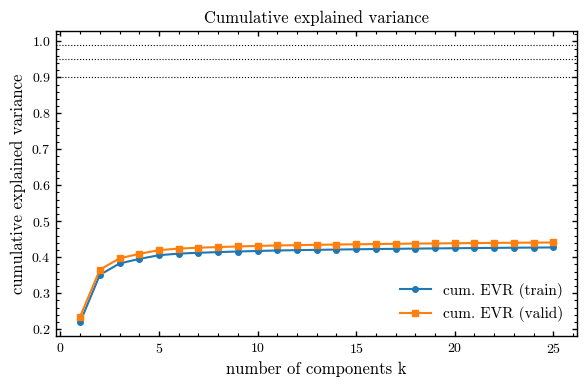

In [59]:
K_MAX = 25
kx = np.arange(1, K_MAX + 1)


for lvl in (0.90, 0.95, 0.99):
    ax.axhline(lvl, color="k", ls=":", lw=0.8)
ax.set_xlabel("number of components k")
ax.set_ylabel("cumulative explained variance")


plt.show()

In [ ]:
# valid_p99, valid_line_p99, valid_line_mean, valid_hisnr_p99

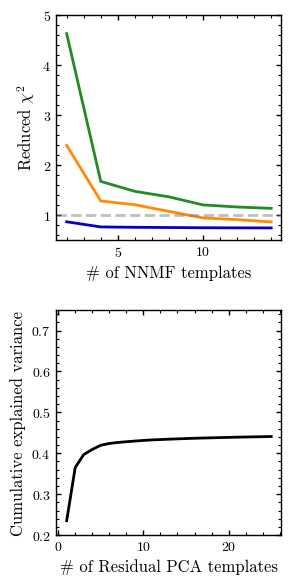

In [69]:
fig,ax = make_subplots(ncol=1,nrow=2,return_fig=True, plot_size=2.25, 
                      col_spacing=[0.5, MARGIN_PAD],
                      row_spacing=[0.6, MARGIN_SPLIT, MARGIN_PAD])

ax[1].plot(n_arr, tab["valid_mean"], color="mediumblue", lw = 2)
ax[1].plot(n_arr, tab["valid_line_mean"], color = "darkorange", lw = 2)
ax[1].plot(n_arr, tab["valid_hisnr_p99"], color = "forestgreen", lw = 2)

ax[1].set_ylim([0.5,5])

ax[1].set_xlabel("# of NNMF templates")
ax[1].set_ylabel(r"Reduced $\chi^2$")

ax[1].axhline(y=1,color="grey",alpha=0.5,ls="--",lw=2)

### pca component stuff, 
cum_evr_valid = d["cum_evr_valid"]
ax[0].plot(kx, cum_evr_valid[:K_MAX], color="k",lw=2)

ax[0].set_ylabel("Cumulative explained variance")
ax[0].set_xlabel("# of Residual PCA templates")
ax[0].set_ylim([0.2,0.75])

plt.show()

In [70]:
# what about all the line ratio variations??

## do we need PCA



## Combined NNMF + residual-PCA template scan

**Panel 1** — reduced $\chi^2$ vs number of NNMF templates (no PCA). Three metrics: `global` (mean over all validation objects; noise-dominated $\sim$0.75, so it's the *evidence for noise-domination*, not the template-count lever), `line region` (8 vacuum lines, $\pm$10 Å), and `hi-S/N tail (p99)` — the 99th-percentile $\chi^2$ among the top-25% S/N objects, which is the discriminating curve (the hi-S/N *mean*, dotted, is flat).

**Panels 2–4** — the *combined* (NNMF + residual-PCA) reduced $\chi^2$ over the full `(n_nmf × n_pca)` grid, colored by global / line-region / hi-S/N-p99. Read via **iso-$\chi^2$ contours** (not the minimum — both axes are monotone). The cyan curve is the per-`n_nmf` **parallel-analysis noise-floor crossing**: beyond it, extra PCA components fit (partly correlated) noise, not shared structure. Dotted white lines mark the production choice (10 NNMF + 20 PCA). The `n_nmf`≈1 bottom edge is $\approx$ pure PCA, so contours vs the constant-total-dimension anti-diagonals give the NNMF$\leftrightarrow$PCA exchange rate.

Data: `scan_nnmf_ntemplates.py` (Panel 1) + `scan_nnmf_pca_grid.py` (grid); submit both via `job_scripts/submit_template_scan.sh`.

In [5]:
import numpy as np
from astropy.table import Table

SCAN_DIR = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/ntemplate_scan"

# Panel 1 data: NNMF-only scan (scan_nnmf_ntemplates.py)
tab = Table.read(f"{SCAN_DIR}/ntemplate_scan_summary.csv")
n_arr = np.array(tab["n_templates"])

# Combined (n_nmf x n_pca) grid (scan_nnmf_pca_grid.py)
gr = np.load(f"{SCAN_DIR}/nnmf_pca_grid_summary.npz")
n_nmf_grid       = gr["n_nmf_grid"]
k_grid           = gr["k_grid"]
first_below_null = gr["first_below_null"]

print("n_nmf grid          :", n_nmf_grid)
print("n_pca grid          :", k_grid[0], "..", k_grid[-1])
print("null-floor crossing :", dict(zip(n_nmf_grid.tolist(), first_below_null.tolist())))
# sanity: grid n_pca=0 column vs pure-NNMF anchor vs Panel-1 valid_mean
print("grid k=0 global     :", np.round(gr["global_redchi2_mean"][:, 0], 3))
print("pure-NNMF anchor    :", np.round(gr["nmf_only_global_mean"], 3))

n_nmf grid          : [ 1  2  4  6  8 10 12 14 16 18 20]
n_pca grid          : 0 .. 25
null-floor crossing : {1: 1, 2: 6, 4: 15, 6: 2, 8: 1860, 10: 1865, 12: 1872, 14: 1872, 16: 1884, 18: 1884, 20: 1890}
grid k=0 global     : [1.277 0.865 0.762 0.755 0.751 0.746 0.744 0.743 0.742 0.741 0.74 ]
pure-NNMF anchor    : [1.309 0.866 0.763 0.755 0.752 0.746 0.744 0.743 0.742 0.741 0.74 ]


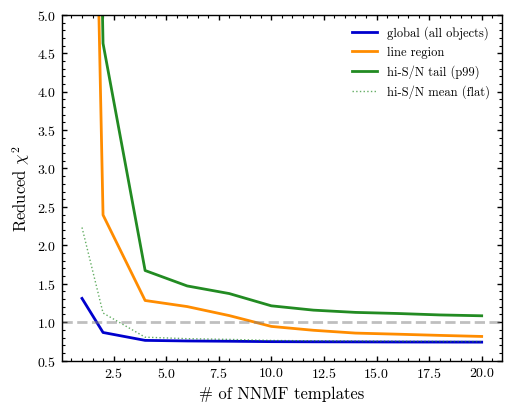

In [6]:
# Panel 1: reduced chi^2 vs number of NNMF templates (NO PCA). Extended grid.
fig, ax = plt.subplots(1, 1, figsize=(5, 4), layout="constrained")

ax.plot(n_arr, tab["valid_mean"],       color="mediumblue",  lw=2, label=r"global (all objects)")
ax.plot(n_arr, tab["valid_line_mean"],  color="darkorange",  lw=2, label=r"line region")
ax.plot(n_arr, tab["valid_hisnr_p99"],  color="forestgreen", lw=2, label=r"hi-S/N tail (p99)")
# the hi-S/N *mean* is noise-floor flat -- shown for contrast (the tail is what moves)
ax.plot(n_arr, tab["valid_hisnr_mean"], color="forestgreen", lw=1, ls=":", alpha=0.7,
        label=r"hi-S/N mean (flat)")

ax.axhline(1, color="grey", alpha=0.5, ls="--", lw=2)
ax.set_xlabel("# of NNMF templates")
ax.set_ylabel(r"Reduced $\chi^2$")
ax.set_ylim([0.5, 5])
ax.legend(frameon=False, fontsize=9)
plt.show()

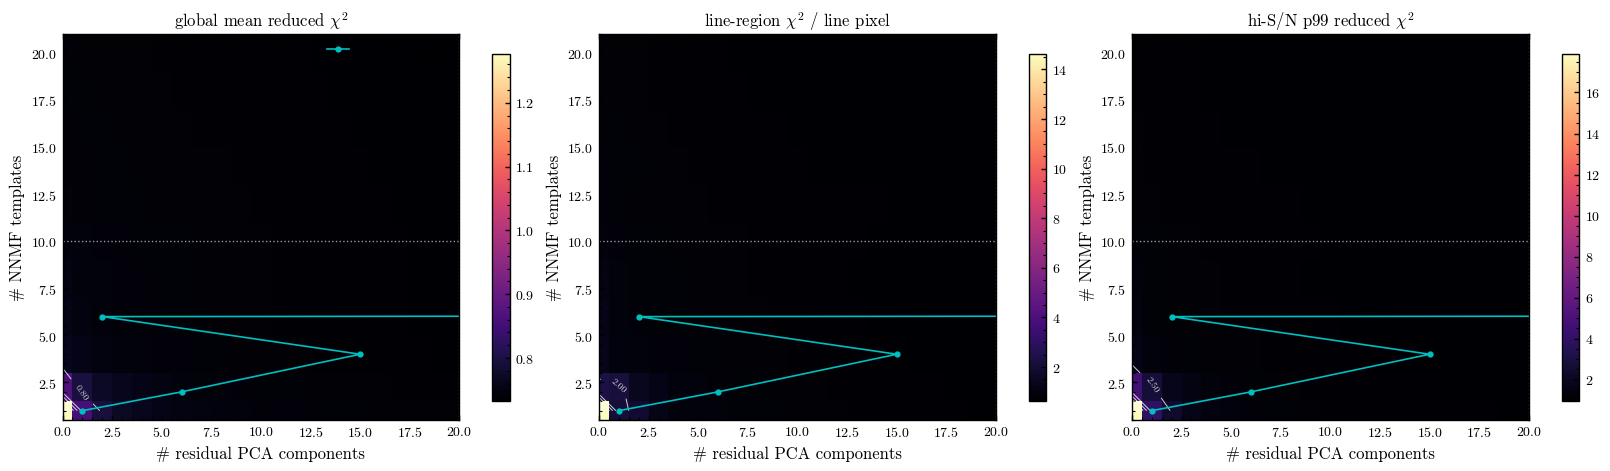

In [8]:
from matplotlib.colors import LogNorm

panels = [
    ("global_redchi2_mean", r"global mean reduced $\chi^2$"),
    ("line_chi2_mean",      r"line-region $\chi^2$ / line pixel"),
    ("hisnr_redchi2_p99",   r"hi-S/N p99 reduced $\chi^2$"),
]

# pcolormesh needs cell edges; build them from the (unequally spaced) centers so
# the n_nmf axis is a true numeric axis (keeps the constant-total-dim
# anti-diagonals meaningful for reading the NNMF<->PCA exchange rate).
def _edges(c):
    c = np.asarray(c, float)
    mid = 0.5 * (c[:-1] + c[1:])
    return np.concatenate([[c[0] - (mid[0] - c[0])], mid, [c[-1] + (c[-1] - mid[-1])]])

kx_e   = _edges(k_grid)
nnmf_e = _edges(n_nmf_grid)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), layout="constrained")
for ax, (key, label) in zip(axes, panels):
    Z = gr[key]
    pm = ax.pcolormesh(kx_e, nnmf_e, Z, cmap="magma", shading="flat")
    cs = ax.contour(k_grid, n_nmf_grid, Z, colors="w", linewidths=0.7, alpha=0.8)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")
    # per-n_nmf parallel-analysis noise-floor crossing: beyond it, extra PCA
    # components are fitting (partly correlated) noise, not shared structure.
    ax.plot(first_below_null, n_nmf_grid, "c.-", lw=1.2, ms=7, label="noise-floor crossing")
    # production choice: 10 NNMF + 20 PCA
    ax.axhline(10, color="w", ls=":", lw=1, alpha=0.6)
    ax.axvline(20, color="w", ls=":", lw=1, alpha=0.6)
    ax.set_xlabel("# residual PCA components")
    ax.set_ylabel("# NNMF templates")
    ax.set_xlim([0,20])
    ax.set_title(label)
    fig.colorbar(pm, ax=ax, shrink=0.9)
axes[0].legend(loc="upper right", fontsize=8, framealpha=0.3)
plt.show()